In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# بارگذاری داده‌های CIFAR-10
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# نرمال‌سازی داده‌ها
x_train, x_test = x_train / 255.0, x_test / 255.0

# تبدیل برچسب‌ها به categorical
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


**data augmentation**

In [2]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)

datagen.fit(x_train)


**Regularization، Dropout و Early Stopping**

In [4]:
model = models.Sequential()

# لایه‌های Convolutional
model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                        kernel_regularizer=regularizers.l2(0.001), input_shape=x_train.shape[1:]))
model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                        kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Dropout(0.25))

# لایه‌های Fully Connected
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

# کامپایل کردن مدل
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Early stopping**

In [5]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


**Data training**

In [6]:
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),
                    steps_per_epoch=x_train.shape[0] // 64,
                    epochs=100,
                    validation_data=(x_test, y_test),
                    callbacks=[early_stopping])


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


781/781 ━━━━━━━━━━━━━━━━━━━━ 51s 55ms/step - accuracy: 0.2767 - loss: 2.3461 - val_accuracy: 0.4771 - val_loss: 1.6311
Epoch 2/100
  1/781 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3125 - loss: 2.1793

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 719us/step - accuracy: 0.3125 - loss: 2.1793 - val_accuracy: 0.4800 - val_loss: 1.6226
Epoch 3/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 69s 46ms/step - accuracy: 0.4469 - loss: 1.7092 - val_accuracy: 0.4942 - val_loss: 1.5591
Epoch 4/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 836us/step - accuracy: 0.5625 - loss: 1.3608 - val_accuracy: 0.4883 - val_loss: 1.5811
Epoch 5/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.4985 - loss: 1.5971 - val_accuracy: 0.5528 - val_loss: 1.4425
Epoch 6/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5781 - loss: 1.5633 - val_accuracy: 0.5630 - val_loss: 1.4156
Epoch 7/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.5276 - loss: 1.5286 - val_accuracy: 0.5922 - val_loss: 1.3591
Epoch 8/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - accuracy: 0.4375 - loss: 1.6312 - val_accuracy: 0.6027 - val_loss: 1.3325
Epoch 9/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.5469 - loss: 1.4939 - val_ac

**Model evaluation**

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7155 - loss: 1.0765
Test accuracy: 0.7127000093460083


**Analysis**

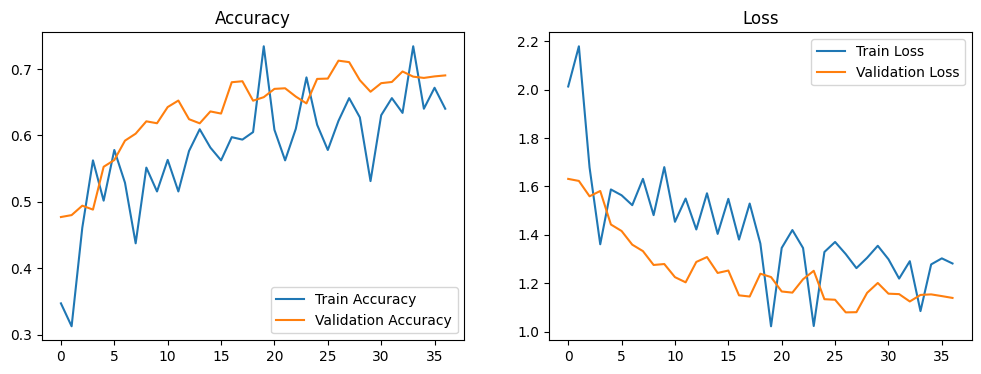

In [8]:
# ترسیم نمودار دقت و Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()
